63


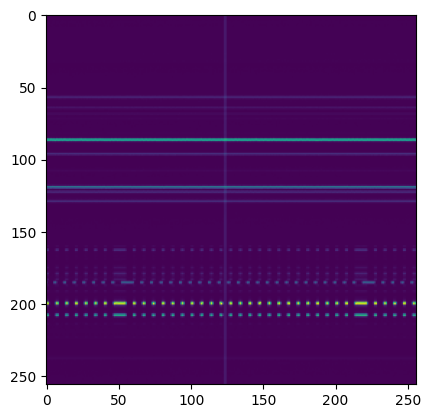

In [86]:
import numpy as np
import sys
sys.path.append('/Users/selbouch/Desktop/Chapter6/injectfrb/injectfrb/')
from simulate_frb import gen_simulated_frb
import spectra
import os
import glob
from copy import deepcopy
import random


def get_array_from_npz(npz_obj, use_db=True):
        if "data" not in npz_obj:
            raise KeyError("Missing 'data' key in npz file")

        sdata = npz_obj["data"].item()
        arr = np.array(sdata.db if use_db else sdata.amp)

        if arr.ndim == 3 and arr.shape[-1] == 1:
            arr = arr[:, :, 0]

        if arr.ndim != 2:
            raise ValueError(f"Expected 2D array, got shape {arr.shape}")

        return arr
class FRBConstants:
    DEFAULT_FLUENCE = 1000
    DEFAULT_SPEC_IND = 0.0
    FREQ_THRESHOLD = 50  
    TIME_EXTENSION_FACTOR = 10  
    DEFAULT_CROP_SIZE = 257
    DEFAULT_CENTER_INDEX = DEFAULT_CROP_SIZE * TIME_EXTENSION_FACTOR // 2
    BAND_LIMIT_CHANNELS = 256

class FRB:
    def __init__(self, param, positive, fmin=400e3, fmax=800e3, dt=0.004):
        self.param = param
        self.dm = param["dm"]
        self.snr = param["snr"]
        self.width_s = param["width_s"]
        self.scat_s = param["scat_s"]
        self.spec_id = param["spec_id"]
        self.positive = positive
        self.dt = dt
        self.n_chann = FRBConstants.BAND_LIMIT_CHANNELS
        self.freq_rang = (fmax,fmin)
        self.freq_list = np.linspace(fmin, fmax, self.n_chann)
        self.freq_ref = (fmax - fmin)//2
        self.sigma = None
        self.simulated_final = None

    def _calculate_noise_statistics(self):
        if self.bg_data is None or self.freq_list is None:
            raise ValueError("Background data must be loaded before calculating noise statistics")

        background_spectra = spectra.Spectra(freqs=self.freq_list,dt=self.dt,data=deepcopy(self.bg_data),starttime=0,dm=self.dm,)
        background_spectra.dedisperse(self.dm, ref_freq=self.freq_ref)
        masked_arr = np.ma.masked_where(background_spectra.data == 0, background_spectra.data)
        profile = np.ma.mean(masked_arr, axis=0)
        self.sigma = np.mean(np.abs(profile - np.ma.mean(profile)))

    def _estimate_pulse_peak(self, integrated):
        max_intergrated = np.max(integrated)
        scale_factor = self.snr*self.sigma/max_intergrated
        return max_intergrated, scale_factor

    def get_data(self):
        if self.simulated_final is None:
            raise ValueError("No simulated data")
        if self.simulated_final.shape[0] == FRBConstants.DEFAULT_CROP_SIZE and self.simulated_final.shape[1] == self.n_chann:
            return np.swapaxes(self.simulated_final, 0, 1)
        else:
            return self.simulated_final


class Generator(FRB):
    def __init__(self, background_dir, param, positive, fmin, fmax, dt):
        super().__init__(param, positive, fmin, fmax, dt)
        self._load_background_nenufar(background_dir, file_idx=0)
        if positive:
            self._calculate_noise_statistics()
            self.simulated_final = self._create_simulation()
        else:
            self.simulated_final = self.bg_data



    def _load_background_nenufar(self, background_dir, file_idx, rebin=True):
        file_pattern = "*.npz"
        files = sorted(glob.glob(os.path.join(background_dir, file_pattern)))
        path = files[file_idx]
        d = np.load(path, allow_pickle=True)
        background = get_array_from_npz(d, use_db=False)
        if rebin:
            rebin_factor = background.shape[1]//256
            rebinned_arr = background.reshape(background.shape[0], rebin_factor, 256).mean(axis=1)
        else:
            rebinned_arr = background
        self.bg_data = np.swapaxes(rebinned_arr, 0, 1) 
        #Todo: add meta data about which frequency band was taken, perhaps also if there is a SRB inside or not

    def _create_simulation(self):
        if self.bg_data is None:
            raise ValueError("Background data must be loaded before creating simulation")
        k_dm = 4.15*1e-3
        sweep_s = k_dm*self.dm*(self.freq_rang[0]**-2 - self.freq_rang[1]**-2)
        total_observation = int(np.ceil((sweep_s + 10*self.scat_s + 0.25)/self.dt)) 
        print(total_observation)
        n_time_long = max(total_observation, self.bg_data.shape[1] * FRBConstants.TIME_EXTENSION_FACTOR)
        large_background = np.zeros((self.bg_data.shape[0], n_time_long))
        frb = gen_simulated_frb(dm=self.dm, fluence = FRBConstants.DEFAULT_FLUENCE, width=self.width_s, NFREQ = large_background.shape[0], NTIME = n_time_long,
                                scat_tau_ref=self.scat_s, scintillate=True, spec_ind=self.spec_id, background_noise=large_background, freq=self.freq_rang, FREQ_REF=self.freq_ref,
                                delta_t = self.dt, conv_dmsmear=False)
        frb_spectra = spectra.Spectra(freqs=self.freq_list, dt=self.dt, data=deepcopy(frb[0]), starttime=0, dm=self.dm)
        frb_spectra.dedisperse(self.dm, ref_freq=self.freq_ref)
        integrated = np.mean(frb_spectra.data, axis=0)
        max_integrated, scale_factor = self._estimate_pulse_peak(integrated)

        self.index_start = random.randint(-10, 10)
        new_center = n_time_long//2 - self.index_start
        crop_start = new_center - FRBConstants.DEFAULT_CROP_SIZE // 2
        crop_end = new_center + FRBConstants.DEFAULT_CROP_SIZE // 2
        frb_cropped = deepcopy(frb[0][:, crop_start:crop_end])
        self.burst = frb_cropped
        final = scale_factor*frb_cropped + deepcopy(self.bg_data[:,1:])

        return final


if __name__=="__main__":
    import matplotlib.pyplot as plt
    %matplotlib inline
    test_frb = FRB(param={"dm":100, "snr":10, "width_s":1e-3, "scat_s":1e-5, "spec_id":0}, positive=True)
    params = {"dm":0, "snr":10, "width_s":1e-3, "scat_s":0, "spec_id":0}
    test_frb_generator = Generator(param=params, positive=True, background_dir="./data_npz/snippetsHF_4768x256_BA", fmin=400, fmax=800, dt=0.004)
    #nenufar_bg = test_frb_generator._load_background_nenufar(background_dir="./data_npz/snippetsHF_4768x256_BA", file_idx=0)
    plt.imshow(test_frb_generator.simulated_final)
    plt.show()
        
        

        


In [87]:
test_frb.freq_ref

200